In [10]:
import pandas as pd
import numpy as np
import seaborn as sns

In [11]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.shape

(7043, 21)

In [14]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [18]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [19]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [20]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [21]:
df =df.drop('customerID',axis=1)

In [22]:
df= pd.get_dummies(df,drop_first=True)

In [23]:
df.dtypes

,0
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
TotalCharges,float64
gender_Male,bool
Partner_Yes,bool
Dependents_Yes,bool
PhoneService_Yes,bool
MultipleLines_No phone service,bool
MultipleLines_Yes,bool


In [45]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

In [46]:
x=df.drop('Churn_Yes',axis=1)
y = df['Churn_Yes']

In [47]:
df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [48]:
df.isnull().sum()

,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,0
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0
MultipleLines_No phone service,0
MultipleLines_Yes,0


In [49]:
df.isnull().sum()

,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,0
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0
MultipleLines_No phone service,0
MultipleLines_Yes,0


<Axes: >

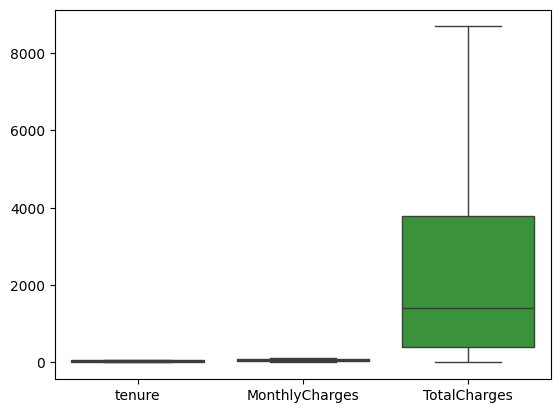

In [50]:
sns.boxplot(df[['tenure','MonthlyCharges','TotalCharges']])

<Axes: >

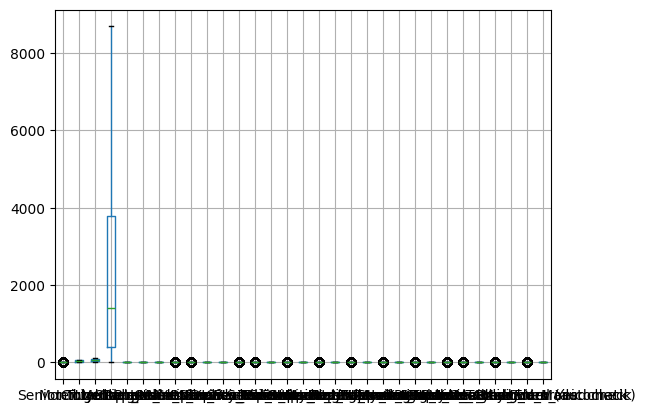

In [51]:
df.boxplot()

In [52]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [57]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=34)

In [58]:
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()

x_train_s = SS.fit_transform(x_train)
x_test_s = SS.transform(x_test)

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

LR=LogisticRegression()
LR.fit(x_train_s,y_train)

y_pred=LR.predict(x_test_s)

LR_accuracy = accuracy_score(y_test,y_pred)

LR_accuracy

0.7821149751596878

In [70]:
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(LR, x_train_s, y_train, cv=5)
cv_score
LR_cv = cv_score.mean()

LR_cv

np.float64(0.8074215801078328)

In [63]:
from sklearn.model_selection import GridSearchCV

classifier = GridSearchCV(LR,{
    'C' : [0.01, 0.1, 1, 10, 100],
    'max_iter' : [100, 200, 500]
},cv=5,return_train_score=False)

In [64]:
classifier.fit(x_train_s,y_train)
classifier.best_params_

{'C': 0.01, 'max_iter': 100}

In [69]:
Grid_score = classifier.best_score_

Grid_score


np.float64(0.8084861962392494)

In [66]:
from sklearn.model_selection import RandomizedSearchCV
classifier_r = RandomizedSearchCV(LR,{
    'C' : [0.01, 0.1, 1, 10, 100],
    'max_iter' : [100, 200, 500]
},n_iter=5,cv=5,return_train_score=False)

In [67]:
classifier_r.fit(x_train_s,y_train)
classifier_r.best_params_

{'max_iter': 200, 'C': 0.01}

In [68]:
classifier_r.best_score_

np.float64(0.8084861962392494)

In [74]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(random_state=34)

RF.fit(x_train,y_train)

y_pred = RF.predict(x_test)

RF_accuracy = accuracy_score(y_test,y_pred)

RF_accuracy

0.7693399574166075

In [75]:
RF_cv_score = cross_val_score(RF,x_train,y_train,cv=5)

RF_cv = RF_cv_score.mean()

RF_cv

np.float64(0.7935757390453285)

In [76]:
models = ['LR','GridSearchCV','RandomizedSearchCV','RF']

scores = [LR_cv,Grid_score,classifier_r.best_score_,RF_cv]

models,scores

(['LR', 'GridSearchCV', 'RandomizedSearchCV', 'RF'],
 [np.float64(0.8074215801078328),
  np.float64(0.8084861962392494),
  np.float64(0.8084861962392494),
  np.float64(0.7935757390453285)])

In [77]:
results = pd.DataFrame({
    'Model' : ['LR','GridSearchCV','RandomizedSearchCV','RF'],
    'CV Score' : [LR_cv,Grid_score,classifier_r.best_score_,RF_cv]
})

results

,Model,CV Score
0,LR,0.807422
1,GridSearchCV,0.808486
2,RandomizedSearchCV,0.808486
3,RF,0.793576


The Logistic Regression baseline provided a strong starting point. After applying GridSearchCV and RandomizedSearchCV, the model performance was compared using cross-validation and test scores. The Random Forest ensemble was also evaluated to determine whether combining multiple decision trees could improve performance.

Overall, the model with the highest CV/Test Score is the preferred model, as it provides the best predictive performance on unseen data. Cross-validation helped ensure that the result was not based on just one train-test split, while hyperparameter tuning helped find better model settings.

Final conclusion: The best-performing model from the comparison table should be selected as the final classifier for predicting customer churn.